# Center-Gap GPQR

In [ ]:
import os

import torch
from torch.distributions import Normal
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import VariationalStrategy
from gpytorch.means import ConstantMean, Mean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
import matplotlib.pyplot as plt

from gpytorch_qr.means import CenterGapMean
from gpytorch_qr.models import CenterGapQuantileGP
from gpytorch_qr.variational import CGLmcVariationalStrategy
from gpytorch_qr.likelihoods import (
    CenterGapQuantileLikelihood,
    MultiOutputQuantileLikelihood,
)

try:
    import sys

    sys.path.insert(0, os.path.abspath(".."))

    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_epochs = 1

## Data preparation

In [ ]:
def mean1(x):
    return torch.cos(x * 2 * 3.14)


def mean2(x):
    return torch.sin(x * 2 * 3.14)


def std(x):
    return x + 0.1


x_range = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
x = x_range.repeat(5, 1)
y1 = mean1(x) + torch.randn(x.shape, device=device).mul(std(x))
y2 = mean2(x) + torch.randn(x.shape, device=device).mul(std(x))
y = torch.concatenate([y1, y2], dim=-1)

q1 = torch.tensor([0.1, 0.5, 0.9], device=device)
true_quantiles1 = mean1(x_range) + Normal(0, std(x_range)).icdf(q1)

q2 = torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9], device=device)
true_quantiles2 = mean2(x_range) + Normal(0, std(x_range)).icdf(q2)

x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

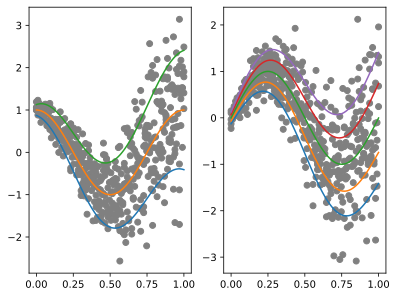

In [ ]:
fig, axes = plt.subplots(1, 2)

axes[0].scatter(x.cpu(), y1.cpu(), c="gray")
axes[0].plot(x_range.cpu(), true_quantiles1.cpu())

axes[1].scatter(x.cpu(), y2.cpu(), c="gray")
axes[1].plot(x_range.cpu(), true_quantiles2.cpu())

fig.show()

## Prior mean

In [ ]:
class PriorMean1(Mean):
    def __init__(self, batch_shape=torch.Size()):
        super().__init__()
        self.batch_shape = batch_shape

    def forward(self, x):
        return mean1(x).squeeze(-1).expand(*self.batch_shape, x.shape[-2])


class PriorMean2(Mean):
    def __init__(self, batch_shape=torch.Size()):
        super().__init__()
        self.batch_shape = batch_shape

    def forward(self, x):
        return mean2(x).squeeze(-1).expand(*self.batch_shape, x.shape[-2])


prior_mean_1 = PriorMean1().to(device)
prior_mean_2 = PriorMean2().to(device)

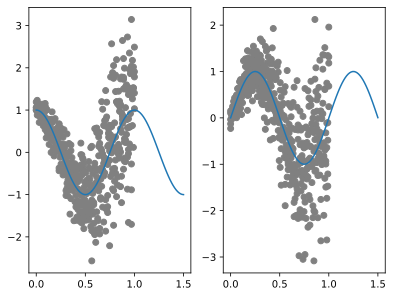

In [ ]:
fig, axes = plt.subplots(1, 2)

axes[0].scatter(x.cpu(), y1.cpu(), c="gray")
axes[0].plot(x_pred.cpu(), prior_mean_1(x_pred).detach().cpu())

axes[1].scatter(x.cpu(), y2.cpu(), c="gray")
axes[1].plot(x_pred.cpu(), prior_mean_2(x_pred).detach().cpu())

fig.show()

## Define model and likelihood

In [ ]:
class MyGP(CenterGapQuantileGP):
    def __init__(
        self,
        inducing_points,
        num_quantiles,
        num_lower_quantiles,
        num_latents,
    ):
        N, D = inducing_points.size()
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([sum(num_latents)]),
        )
        variational_strategy = CGLmcVariationalStrategy(
            VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True,
            ),
            num_quantiles=num_quantiles,
            num_lower_quantiles=num_lower_quantiles,
            num_latents=num_latents,
        )

        mean = CenterGapMean(
            torch.nn.ModuleList(
                [
                    PriorMean1(batch_shape=torch.Size([1])),
                    PriorMean2(batch_shape=torch.Size([1])),
                ]
            ),
            ConstantMean(batch_shape=torch.Size([sum(num_latents) - 2])),
        )
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=torch.Size([sum(num_latents)])),
            batch_shape=torch.Size([sum(num_latents)]),
        )
        super().__init__(
            variational_strategy, mean, covar, num_quantiles, num_lower_quantiles
        )


inducing_points = torch.linspace(0, 1, 10).reshape(-1, 1).to(device)
central_q1_index = (q1 - 0.5).abs().argmin().item()
central_q2_index = (q2 - 0.5).abs().argmin().item()
gp = MyGP(
    inducing_points,
    [len(q1), len(q2)],
    [central_q1_index, central_q2_index],
    [len(q1) - 1, len(q2) - 1],
).to(device)
likelihood = MultiOutputQuantileLikelihood(
    CenterGapQuantileLikelihood(q1, central_q1_index),
    CenterGapQuantileLikelihood(q2, central_q2_index),
).to(device)

## Train

In [ ]:
gp.train()
likelihood.train()
mll = VariationalELBO(likelihood, gp, num_data=len(y))
optimizer = torch.optim.Adam(
    list(gp.parameters()) + list(likelihood.parameters()),
    lr=0.001,
)

for _ in range(n_epochs):
    output = gp(x)
    loss = -mll(output, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [ ]:
gp.eval()
with torch.no_grad():
    mean_q = gp.mean_quantiles_mc(x_pred)
    lower_q, upper_q = gp.quantile_quantiles_mc(
        x_pred, torch.tensor([0.025, 0.975]).to(device)
    )

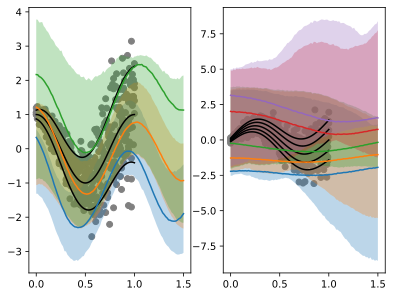

In [ ]:
fig, axes = plt.subplots(1, 2)

axes[0].scatter(x.cpu(), y1.cpu(), c="gray")
axes[0].plot(x_range.cpu(), true_quantiles1.cpu(), color="k")
for i in range(len(q1)):
    axes[0].plot(x_pred.cpu(), mean_q[:, i].cpu(), label=f"q={q1[i].item():.2f}")
    axes[0].fill_between(
        x_pred.cpu().squeeze(),
        lower_q[:, i].cpu(),
        upper_q[:, i].cpu(),
        alpha=0.3,
    )

axes[1].scatter(x.cpu(), y2.cpu(), c="gray")
axes[1].plot(x_range.cpu(), true_quantiles2.cpu(), color="k")
for i in range(len(q2)):
    axes[1].plot(
        x_pred.cpu(), mean_q[:, len(q1) + i].cpu(), label=f"q={q2[i].item():.2f}"
    )
    axes[1].fill_between(
        x_pred.cpu().squeeze(),
        lower_q[:, len(q1) + i].cpu(),
        upper_q[:, len(q1) + i].cpu(),
        alpha=0.3,
    )

fig.show()